# 01 – Data exploration

First look at the mining flotation dataset: structure, time gaps, silica behaviour, and filled-in lab values.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
print(Path.cwd())

/Users/majdalsuleh/Projects/mining-quality-prediction


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/MiningProcess_Flotation_Plant_Database.csv",
                 decimal=",", parse_dates=["date"])
df.shape

(737453, 24)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[us]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11  Flotation Column 04 Air 

In [4]:
print(df.isna().sum().sum(), "missing values")
print(df["date"].min(), "to", df["date"].max())

0 missing values
2017-03-10 01:00:00 to 2017-09-09 23:00:00


In [5]:
rows_per_hour = df["date"].value_counts()
rows_per_hour.value_counts().head()

count
180    4095
179       1
174       1
Name: count, dtype: int64

Data is recorded every 20 seconds, giving 180 readings per hour. Only 2 of 4,097 hours are incomplete (179 and 174 readings), so the data is very consistent within each hour.

In [6]:
hours = df["date"].drop_duplicates().sort_values()
gaps = hours.diff()
gaps[gaps > pd.Timedelta("1h")]

26814   13 days 07:00:00
Name: date, dtype: timedelta64[us]

In [7]:
gap_end = hours.loc[26814]
gap_start = gap_end - gaps.loc[26814]
print("Data stops:", gap_start)
print("Data restarts:", gap_end)

Data stops: 2017-03-16 05:00:00
Data restarts: 2017-03-29 12:00:00


There is one gap with no data from 16 March 2017, 05:00 to 29 March 2017, 12:00 (about 13 days). Only about 6 days of data come before it. For modeling, I'll use only the continuous period from 29 March onward, so that time-based features (like "last hour's silica") are never calculated across missing days.

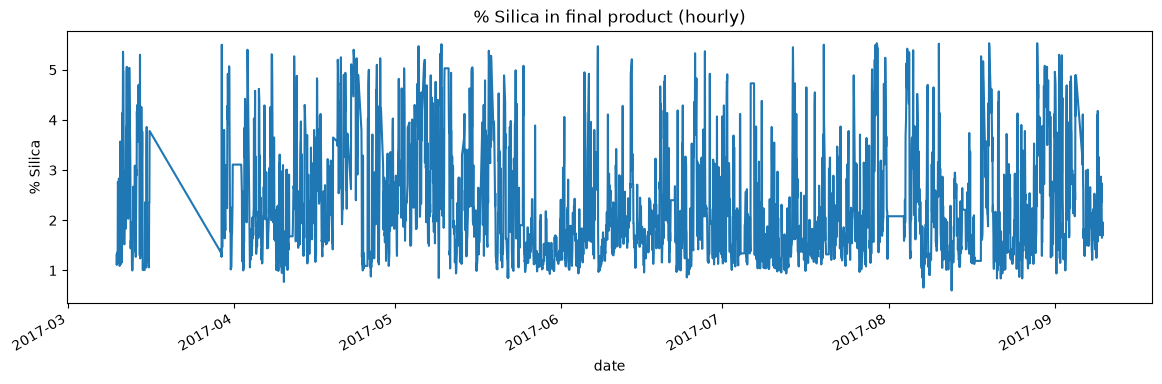

In [8]:
hourly = df.groupby("date")["% Silica Concentrate"].mean()
hourly.plot(figsize=(14, 4), title="% Silica in final product (hourly)")
plt.ylabel("% Silica")
plt.show()

Silica in the final product ranges from about 0.6% to 5.5%, mostly between 1.5% and 3%, and changes a lot from hour to hour. Mid-May to July is calmer and lower; April and August–September are more volatile, with more spikes above 4%.

In [9]:
flat = hourly.diff().eq(0)
group = (~flat).cumsum()
runs = hourly.groupby(group).agg(
    start=lambda s: s.index[0],
    end=lambda s: s.index[-1],
    hours="size",
    value="first",
)
runs[runs["hours"] >= 6].sort_values("hours", ascending=False)

,start,end,hours,value
% Silica Concentrate,,,,
2821,2017-07-31 20:00:00,2017-08-03 20:00:00,73,2.08
181,2017-03-31 17:00:00,2017-04-02 07:00:00,39,3.11
3117,2017-08-17 02:00:00,2017-08-18 05:00:00,28,1.19
1039,2017-05-10 05:00:00,2017-05-10 23:00:00,19,5.03
1978,2017-06-21 09:00:00,2017-06-22 03:00:00,19,2.40
2240,2017-07-04 11:00:00,2017-07-05 03:00:00,17,1.34
389,2017-04-11 06:00:00,2017-04-11 21:00:00,16,1.68
2264,2017-07-06 07:00:00,2017-07-06 22:00:00,16,4.73
698,2017-04-25 06:00:00,2017-04-25 20:00:00,15,1.09


In [10]:
step = hourly.diff().round(4)
same_step = step.eq(step.shift()) & step.ne(0)
group2 = (~same_step).cumsum()
lines = hourly.groupby(group2).agg(
    start=lambda s: s.index[0],
    end=lambda s: s.index[-1],
    hours="size",
)
lines[lines["hours"] >= 6]

,start,end,hours
% Silica Concentrate,,,
268,2017-04-03 13:00:00,2017-04-03 21:00:00,9
630,2017-04-19 12:00:00,2017-04-20 03:00:00,16
675,2017-04-22 04:00:00,2017-04-22 17:00:00,14
679,2017-04-22 21:00:00,2017-04-23 04:00:00,8
697,2017-04-24 04:00:00,2017-04-24 16:00:00,13
784,2017-04-28 10:00:00,2017-04-28 17:00:00,8
895,2017-05-03 10:00:00,2017-05-03 15:00:00,6
952,2017-05-06 02:00:00,2017-05-06 08:00:00,7
1119,2017-05-13 13:00:00,2017-05-13 19:00:00,7


In [11]:
filled = pd.Series(False, index=hourly.index)

# Flat stretches: first hour is real, the copies after it are filled
for _, r in runs[runs["hours"] >= 6].iterrows():
    filled.loc[r["start"]:r["end"]] = True
    filled.loc[r["start"]] = False

# Straight lines: last hour is the real end point, the hours before it are filled
for _, r in lines[lines["hours"] >= 6].iterrows():
    filled.loc[r["start"]:r["end"]] = True
    filled.loc[r["end"]] = False

print(filled.sum(), "filled hours out of", len(filled))
print(f"{filled.mean():.1%} of hours")

448 filled hours out of 4097
10.9% of hours


Filled-in silica values. About 10.9% of hours (448 hours) look filled in rather than measured, in two forms:
- Flat stretches: 19 stretches where silica stays exactly the same for 6+ hours (longest: 73 hours, 31 Jul–3 Aug).
- Straight lines: 14 stretches where silica changes by the exact same amount every hour (longest: 26 hours, 5–6 Sep).

Rule: 6+ hours in a row of either pattern is marked as filled. The first hour of a flat stretch and the end point of a straight line are kept as real results. Filled hours are marked in an is_filled column and left out of model training and testing, so neither the model nor the baseline gets credit for predicting fake values.

In [12]:
filled.rename("is_filled").to_csv("data/filled_hours.csv")

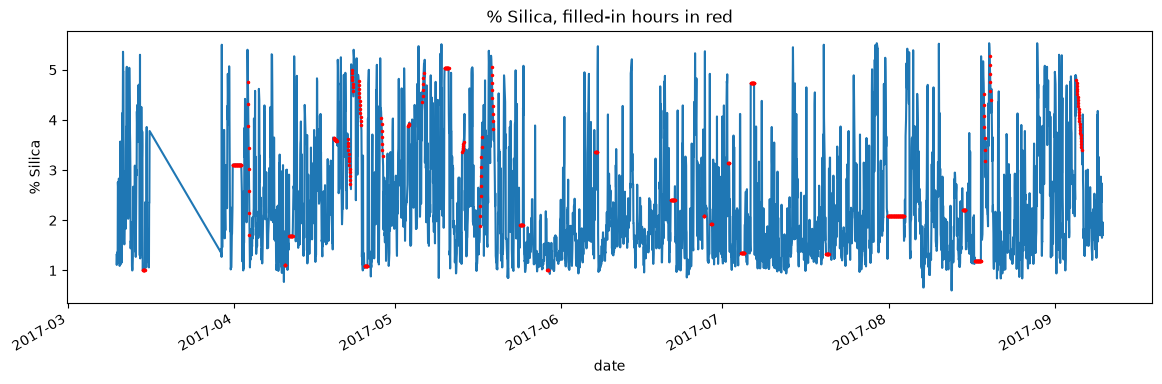

In [13]:
ax = hourly.plot(figsize=(14, 4), title="% Silica, filled-in hours in red")
hourly[filled].plot(ax=ax, style="r.", markersize=3)
plt.ylabel("% Silica")
plt.savefig("reports/silica_filled_hours.png", dpi=150, bbox_inches="tight")
plt.show()

## Sensors

In [14]:
hourly_all = df.groupby("date").mean()
hourly_all.shape

(4097, 23)

In [15]:
hourly_all.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
% Iron Feed,4097.0,56.29,5.16,42.74,52.67,56.08,59.72,65.78
% Silica Feed,4097.0,14.65,6.81,1.31,8.94,13.85,19.60,33.40
Starch Flow,4097.0,2869.14,950.48,54.60,2168.97,2908.34,3528.73,6270.16
Amina Flow,4097.0,488.15,83.69,242.93,436.04,502.45,549.52,736.98
Ore Pulp Flow,4097.0,397.58,8.37,376.84,398.85,399.84,400.59,418.07
Ore Pulp pH,4097.0,9.77,0.38,8.75,9.54,9.80,10.03,10.81
Ore Pulp Density,4097.0,1.68,0.06,1.52,1.65,1.70,1.72,1.83
Flotation Column 01 Air Flow,4097.0,280.15,29.41,175.89,250.09,299.84,299.95,312.30
Flotation Column 02 Air Flow,4097.0,277.16,29.42,178.19,250.10,299.53,299.98,309.89
Flotation Column 03 Air Flow,4097.0,281.08,28.37,177.20,250.09,299.89,299.95,302.78


In [16]:
real = hourly_all[~filled]
corr = real.corr()["% Silica Concentrate"].drop("% Silica Concentrate")
corr.sort_values().round(2)

% Iron Concentrate             -0.79
Flotation Column 04 Level      -0.20
Flotation Column 05 Level      -0.19
Flotation Column 07 Level      -0.16
Flotation Column 01 Air Flow   -0.16
Flotation Column 03 Air Flow   -0.16
Flotation Column 06 Level      -0.14
Ore Pulp pH                    -0.13
Flotation Column 02 Air Flow   -0.13
% Iron Feed                    -0.06
Starch Flow                    -0.06
Flotation Column 07 Air Flow   -0.04
Flotation Column 03 Level      -0.02
Flotation Column 04 Air Flow   -0.00
Flotation Column 06 Air Flow   -0.00
Flotation Column 05 Air Flow   -0.00
Flotation Column 02 Level       0.00
Flotation Column 01 Level       0.01
Ore Pulp Flow                   0.01
% Silica Feed                   0.05
Ore Pulp Density                0.09
Amina Flow                      0.21
Name: % Silica Concentrate, dtype: float64

Sensors. Most air flows (columns 1–3, 6, 7) sit at a setting of about 300 and only sometimes drop. Air flow in columns 4–5 and ore pulp flow are nearly constant, so they carry little information. Tank levels and the incoming ore vary a lot.

Links with silica (real hours only). Iron concentrate is strongly linked (-0.79), which confirms it would leak the answer, so it is left out. No real sensor is strongly linked on its own (all within ±0.21), so the model must combine many of them. Strongest: amina flow (+0.21), levels of columns 4, 5 and 7 (about -0.2), air flow of columns 1 and 3 (-0.16), and pH (-0.13).

Amina is positively linked to silica, even though amina is used to remove silica. A possible explanation is that operators increase amina when silica rises, so the setting reacts to quality instead of causing it. Correlation here does not show cause.

In [17]:
changes = (hourly_all.diff() != 0).mean().sort_values()
changes.round(3)

% Iron Feed                     0.075
% Silica Feed                   0.075
Flotation Column 04 Air Flow    0.887
Flotation Column 05 Air Flow    0.887
% Iron Concentrate              0.889
% Silica Concentrate            0.891
Ore Pulp pH                     0.997
Flotation Column 06 Air Flow    0.998
Flotation Column 07 Air Flow    0.998
Flotation Column 03 Air Flow    0.998
Flotation Column 01 Air Flow    0.998
Flotation Column 02 Air Flow    0.998
Flotation Column 01 Level       0.999
Ore Pulp Density                0.999
Flotation Column 05 Level       0.999
Starch Flow                     1.000
Amina Flow                      1.000
Flotation Column 02 Level       1.000
Flotation Column 03 Level       1.000
Flotation Column 04 Level       1.000
Flotation Column 06 Level       1.000
Flotation Column 07 Level       1.000
Ore Pulp Flow                   1.000
dtype: float64

Iron feed and silica feed change in only 7.5% of hours (about every 13 hours), so they appear to be periodic samples of the incoming ore held between updates, not live readings. This likely explains why silica in the feed has almost no hour-by-hour link to silica in the product. The two lab results stay unchanged in about 11% of hours, which matches the 10.9% filled hours found earlier. Air flow in columns 4 and 5 is also unchanged in about 11% of hours and barely varies otherwise, so these two columns carry little information. All other sensors change almost every hour.